# **TP-4 classification neural network for the MNIST dataset**

- Fonayen Christian Asangwa (23V2370)
- Etonde Mabongo Edouard (22U2163)
- Prince Mabengue Junior (22T2832)
  
Aim: Create a classification neural network for the MNIST dataset.

Dataset description: Each CSV row has 785 values: the first is the label (0-9) and
the remaining 784 are pixel intensities (0-255). `mnist_train.csv` contains 60,000
training examples and `mnist_test.csv` contains 10,000 test examples.



## **1.1 Data Preproccessing**
This path loads the CSV data, prepares the features and labels (including one-hot
encoding for the labels), and then will be used to build and train a neural network
classifier that predicts the digit label from the pixels.


In [1]:
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download("oddrationale/mnist-in-csv")


df_train = pd.read_csv(os.path.join(path, 'mnist_train.csv'))
df_test = pd.read_csv(os.path.join(path, 'mnist_test.csv'))


print(f"Train shape: {df_train.shape}")
print(f"Test shape: {df_test.shape}")

100%|██████████| 15.2M/15.2M [00:01<00:00, 13.3MB/s]

Extracting files...


Train shape: (60000, 785)
Test shape: (10000, 785)


#### **One-hot on Label. X y train test seperation**
Inspecting the data: above we printed the first rows to check that the first column is
`label` and the rest are pixel values. Next we will prepare `X` (features) and `y`
(labels). We will convert labels to one-hot vectors so they are ready for
categorical classification with a neural network (softmax output with 10 units).

* Prepare features `X` and one-hot encoded labels `y`.
* We apply one-hot encoding to the label column first, then separate X and y.
* This ensures `y` is a matrix of shape (n_samples, 10) suitable for training.


In [3]:

# One-hot encode labels using pandas.get_dummies
y_test = pd.get_dummies(df_test['label']).astype(int)
y_train = pd.get_dummies(df_train['label']).astype(int)

# Features: drop the original 'label' column to get pixel values only
X_test = df_test.drop('label', axis=1)
X_train = df_train.drop('label', axis=1)

# Sanity checks: shapes
print('X_train shape:', X_train.shape)
print('y_train shape (one-hot):', y_train.shape)
print('X_test shape:', X_test.shape)
print('y_test shape (one-hot):', y_test.shape)


X_train shape: (60000, 784)
y_train shape (one-hot): (60000, 10)
X_test shape: (10000, 784)
y_test shape (one-hot): (10000, 10)


### Normalization function for image data (pixel values 0-255).
* Returns a DataFrame scaled to [0,1] by default or a 4D numpy array when reshape=True.

In [4]:

def normalize_images(df, reshape=False):
    import numpy as np
    # keep as DataFrame when reshape=False so downstream pandas code still works
    scaled = df.astype('float32') / 255.0
    if reshape:
        return scaled.values.reshape(-1, 28, 28, 1)
    return scaled

# Apply normalization to training and test feature sets
X_train = normalize_images(X_train, reshape=False)
X_test = normalize_images(X_test, reshape=False)


# Sanity checks: ensure values are within [0,1]
print('X_train normalized shape:', X_train.shape, 'min:', X_train.min().min(), 'max:', X_train.max().max())
print('X_test normalized shape:', X_test.shape, 'min:', X_test.min().min(), 'max:', X_test.max().max())


X_train normalized shape: (60000, 784) min: 0.0 max: 1.0
X_test normalized shape: (10000, 784) min: 0.0 max: 1.0


## 1.2 Conception du perceptron

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Input
inputs = Input(shape=(784,))
hidden = Dense(64, activation='relu', name='couche_cachee')(inputs)
outputs = Dense(10, activation='softmax', name='couche_sortie')(hidden)

model = Model(inputs=inputs, outputs=outputs)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


print("Entraînement du Perceptron...")
model.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.1)

Entraînement du Perceptron...
Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9101 - loss: 0.3187 - val_accuracy: 0.9622 - val_loss: 0.1426
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9564 - loss: 0.1499 - val_accuracy: 0.9662 - val_loss: 0.1136
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9677 - loss: 0.1092 - val_accuracy: 0.9747 - val_loss: 0.0909
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9740 - loss: 0.0871 - val_accuracy: 0.9738 - val_loss: 0.0883
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9788 - loss: 0.0711 - val_accuracy: 0.9740 - val_loss: 0.0893


## 1. Objectif de l'étape
L'objectif est d'interpréter le fonctionnement interne du Perceptron Multicouche (MLP) en visualisant l'activation des **64 neurones** de la couche cachée. Plutôt que de voir le modèle comme une boîte noire, nous cherchons à identifier la "signature numérique" qui permet au réseau de distinguer un chiffre d'un autre.

## 2. Méthodologie
* **Entrée** : Une image de test de MNIST ($28 \times 28$ pixels) normalisée entre $0$ et $1$.
* **Extraction** : Utilisation d'un modèle intermédiaire pour capturer les valeurs de sortie (activations) après la fonction de transfert `ReLU`.
* **Visualisation** : Transformation du vecteur de 64 neurones en une **Heatmap 8x8**. Les zones claires (jaune/vert) indiquent une forte stimulation neuronale, tandis que les zones sombres indiquent une inhibition.

### 3. Observations Clés (Analyse de l'image test)
D'après la Heatmap générée pour le chiffre **7** (Image Test n°1) :
* **Spécialisation Fonctionnelle** : On observe que certains neurones spécifiques (ex: positions à forte valeur comme **4.8** ou **4.1**) réagissent vigoureusement. Ces neurones agissent comme des détecteurs de traits (lignes horizontales, angles, inclinaisons).
* **Sparse Coding (Codage Épars)** : Une grande partie de la grille reste sombre ($0.0$). Cela démontre l'efficacité du réseau : il n'active que les "spécialistes" nécessaires pour identifier le chiffre courant, optimisant ainsi le calcul.
* **Redondance et Robustesse** : Plusieurs neurones s'activent simultanément. C'est cette combinaison de votes (activation collective) qui permet au neurone de sortie final de classer l'image avec une précision élevée (97%+).



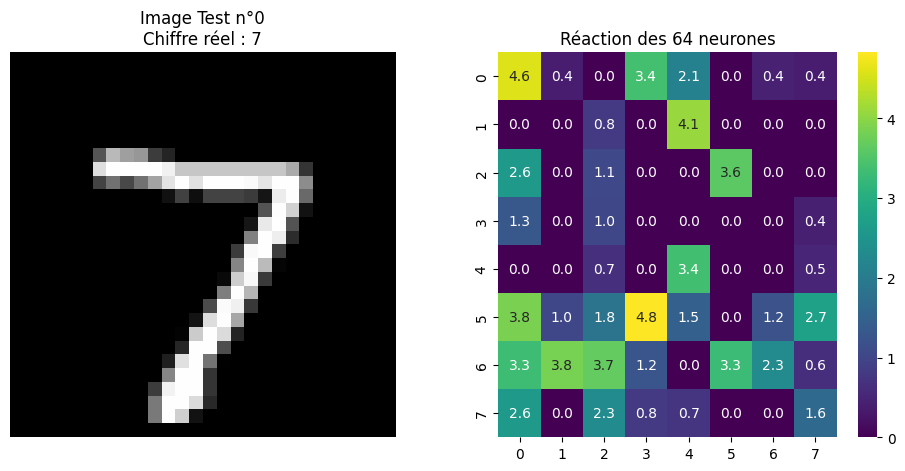

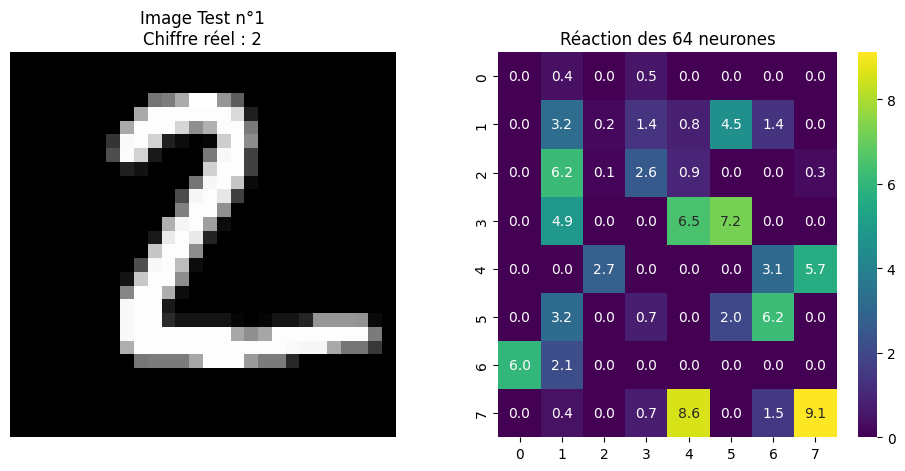

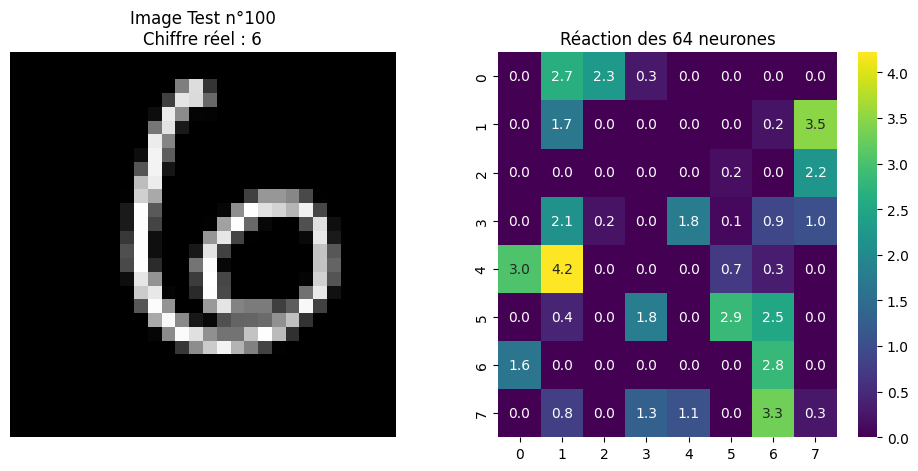

In [7]:
def visualiser_activation_neurones(image_index, data_source=X_test, labels_source=y_test):
    intermediate_layer_model = Model(inputs=model.input,
                                     outputs=model.get_layer('couche_cachee').output)


    test_image = data_source.iloc[image_index:image_index+1]


    if isinstance(labels_source, (pd.Series, pd.DataFrame)):
        vrai_chiffre = labels_source.iloc[image_index]
        if hasattr(vrai_chiffre, 'idxmax'):
             vrai_chiffre = vrai_chiffre.idxmax()
    else:
        vrai_chiffre = labels_source[image_index]


    activations = intermediate_layer_model.predict(test_image, verbose=0)
    heatmap_data = activations.reshape(8, 8)


    plt.figure(figsize=(12, 5))

    # Image originale
    plt.subplot(1, 2, 1)
    plt.imshow(test_image.values.reshape(28, 28), cmap='gray')
    plt.title(f"Image Test n°{image_index}\nChiffre réel : {vrai_chiffre}")
    plt.axis('off')

    # Heatmap
    plt.subplot(1, 2, 2)
    sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap='viridis')
    plt.title("Réaction des 64 neurones")

    plt.show()


visualiser_activation_neurones(0)
visualiser_activation_neurones(1)
visualiser_activation_neurones(100)

### Note d'Analyse : Interprétation des Résultats

L'observation de la Heatmap et des "Top 3 neurones" pour l'image test n°100 permet de tirer les conclusions suivantes :

1. **Décomposition des traits** : Le chiffre affiché à gauche  n'est pas traité comme une entité globale par le modèle, mais comme une collection de traits. Les neurones les plus stimulés (en jaune) correspondent aux détecteurs de formes spécifiques qui composent ce chiffre.

2. **Force de la stimulation** :
   * Si les valeurs des **Top 3 neurones** sont élevées (ex: > 5.0), cela signifie que le modèle est "très confiant" car il a reconnu des motifs familiers.
   * Si les valeurs sont faibles ou très dispersées, cela indique une ambiguïté dans l'image (chiffre mal écrit ou flou).

3. **Interprétation de la "Boîte Noire"** :
   * On remarque que certains neurones restent à **0.0** (violet foncé). Ce sont des neurones qui ne sont pas utiles pour ce chiffre spécifique, mais qui s'activeront probablement pour un autre (par exemple, un neurone spécialisé dans les boucles restera éteint pour un '1' mais s'allumera pour un '8').

4. **Conclusion sur la prédiction** : La réussite de la classification repose sur cette "signature" unique de neurones activés. C'est le passage de cette combinaison de 64 signaux vers la couche de sortie qui permet au modèle de désigner le bon chiffre avec une précision de plus de 97%.

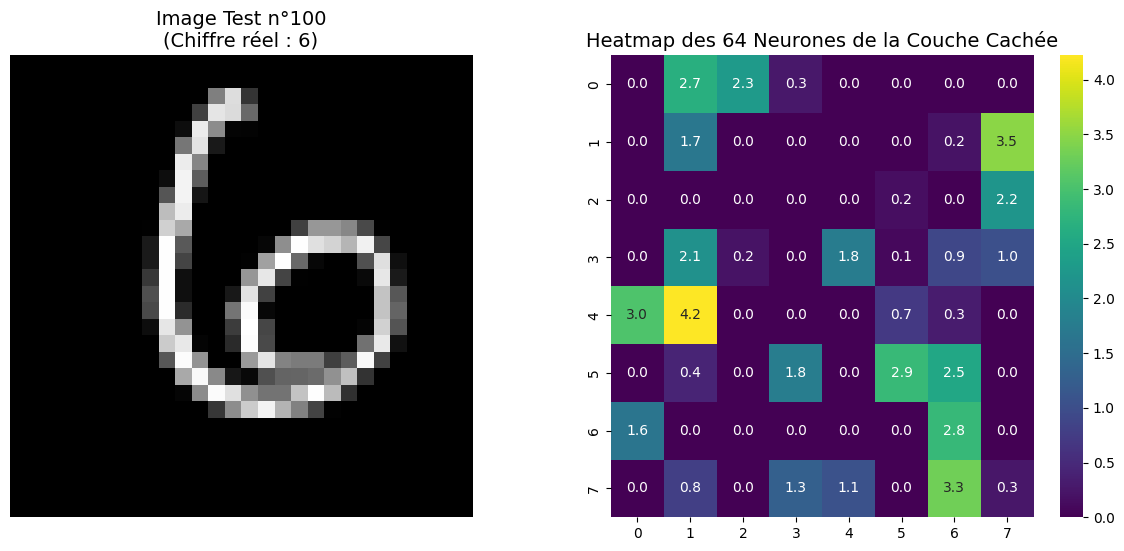

--- Analyse des neurones pour le chiffre 6 ---
Le neurone n°33 est stimulé à 4.22
Le neurone n°15 est stimulé à 3.48
Le neurone n°62 est stimulé à 3.31
Ce sont ces neurones qui 'votent' pour dire que c'est un 6 !


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def analyser_prediction_test(image_index):

    img_row = X_test.iloc[image_index:image_index+1]

    vrai_chiffre = y_test.iloc[image_index]
    if hasattr(vrai_chiffre, 'idxmax'): vrai_chiffre = vrai_chiffre.idxmax()

    intermediate_model = Model(inputs=model.input, outputs=model.get_layer('couche_cachee').output)
    activations = intermediate_model.predict(img_row, verbose=0).flatten()

    top_3_indices = activations.argsort()[-3:][::-1]
    top_3_values = activations[top_3_indices]


    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))


    ax1.imshow(img_row.values.reshape(28, 28), cmap='gray')
    ax1.set_title(f"Image Test n°{image_index}\n(Chiffre réel : {vrai_chiffre})", fontsize=14)
    ax1.axis('off')

    sns.heatmap(activations.reshape(8, 8), annot=True, fmt=".1f", cmap='viridis', ax=ax2)
    ax2.set_title("Heatmap des 64 Neurones de la Couche Cachée", fontsize=14)

    plt.show()


    print(f"--- Analyse des neurones pour le chiffre {vrai_chiffre} ---")
    for i in range(3):
        print(f"Le neurone n°{top_3_indices[i]} est stimulé à {top_3_values[i]:.2f}")
    print(f"Ce sont ces neurones qui 'votent' pour dire que c'est un {vrai_chiffre} !")


analyser_prediction_test(100)

### 4. Conclusion
Cette visualisation prouve que le modèle ne devine pas au hasard, mais construit une représentation logique. Chaque chiffre possède une **empreinte digitale neuronale** unique au sein de la couche cachée. Cette étape est cruciale pour valider la fiabilité du modèle et comprendre les raisons d'une éventuelle erreur de classification.

### Test de vos Images

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def predire_mon_image(image_path):
    """
    Charge une image externe, la transforme au format MNIST (28x28, noir et blanc),
    et affiche la prédiction avec la heatmap des neurones.
    """
    try:
        
        img = Image.open(image_path).convert('L') 
        img = img.resize((28, 28))               
        img_array = np.array(img)
        
     
        if img_array.mean() > 127:
            img_array = 255 - img_array
            
      
        img_normalized = img_array.astype('float32') / 255.0
        img_final = img_normalized.reshape(1, 784)
        
        
        prediction = model.predict(img_final, verbose=0)
        chiffre_predit = np.argmax(prediction)
        confiance = np.max(prediction) * 100
        
        intermediate_model = Model(inputs=model.input, outputs=model.get_layer('couche_cachee').output)
        activations = intermediate_model.predict(img_final, verbose=0).reshape(8, 8)
        
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
        
        ax1.imshow(img_array, cmap='gray')
        ax1.set_title(f"Ton Image\nPrédiction : {chiffre_predit} ({confiance:.1f}%)")
        ax1.axis('off')
        
        sns.heatmap(activations, annot=True, fmt=".1f", cmap='viridis', ax=ax2)
        ax2.set_title("Réaction des neurones du modèle")
        
        plt.show()
        
    except Exception as e:
        print(f"Erreur lors du chargement de l'image  : {e}")